In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("smartcart_customers.csv")

## Preprocessing

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [5]:
df['Income'] = df['Income'].fillna(df['Income'].mean())

In [6]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

## Feature Engineering

In [7]:
## Year Birth -> age

df['age'] = 2026 - df['Year_Birth']

In [8]:
## categorizing education values

print(df['Education'].value_counts())

df['Education'] = df['Education'].replace({
    "Graduation" : "Graduate",
    "PhD" : "Post Graduate", "Master" : "Post Graduate",
    "2n Cycle" : "Undergraduate", "Basic" : "Undergraduate"
})

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64


In [9]:
## categorizing marital status values

print(df['Marital_Status'].value_counts())

df["Living_With"] = df["Marital_Status"].replace({
    "Married": "Partner", "Together": "Partner",
    "Single": "Alone", "Divorced": "Alone",
    "Widow": "Alone", "Absurd": "Alone", "YOLO": "Alone"
})

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64


In [10]:
## kidhome and teenhome to one feature

df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [11]:
## Customer joining date to days

df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)

ref_date = df['Dt_Customer'].max()

df['Tenure_Days'] = (ref_date - df['Dt_Customer']).dt.days

In [12]:
## all spending in one feature

df['Total_Spends'] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']

In [13]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'age', 'Living_With', 'Total_Children',
       'Tenure_Days', 'Total_Spends'],
      dtype='str')

## Drop Columns

In [14]:
cols = ['ID', 'Year_Birth', 'Marital_Status', 'Kidhome', 'Teenhome', 'Dt_Customer']
spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

cols_to_drop = cols + spending_cols

df_cleaned = df.drop(columns=cols_to_drop)

In [15]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,Living_With,Total_Children,Tenure_Days,Total_Spends
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,Alone,0,663,1617
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,Alone,2,113,27
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,Partner,0,312,776
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,Partner,1,139,53
4,Post Graduate,58293.0,94,5,5,3,6,5,0,0,45,Partner,1,161,422


In [16]:
df_cleaned.shape

(2240, 15)

## Outliers

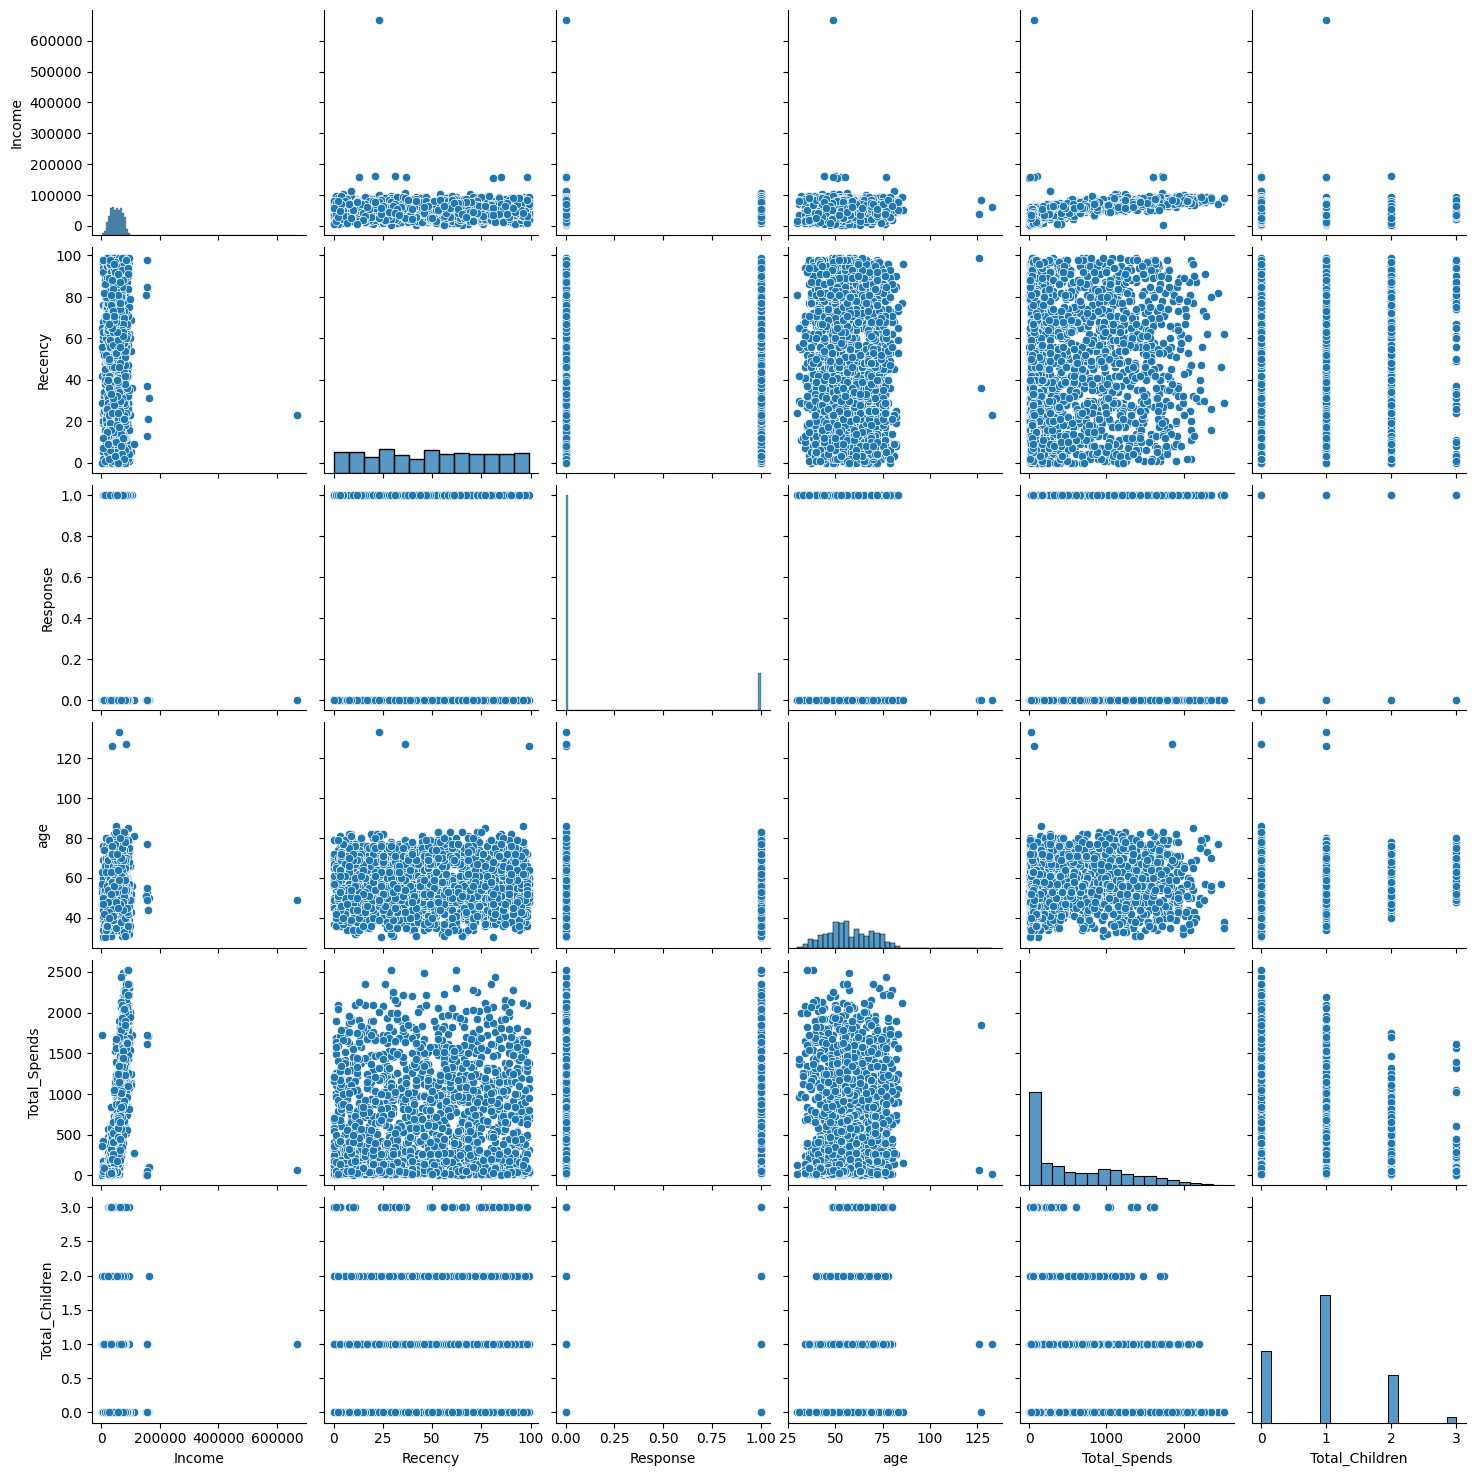

In [17]:
cols = ["Income", "Recency", "Response", "age", "Total_Spends", "Total_Children"]

# relative plots of some features-  pair plots
sns.pairplot(df_cleaned[cols])

In [18]:
print("data size with outliers:", len(df_cleaned))

df_cleaned = df_cleaned[ (df_cleaned["age"] < 90) ]
df_cleaned = df_cleaned[ (df_cleaned["Income"] < 600_000) ]

print("data size without outliers:", len(df_cleaned))

data size with outliers: 2240
data size without outliers: 2236


## Heatmap

<Axes: >

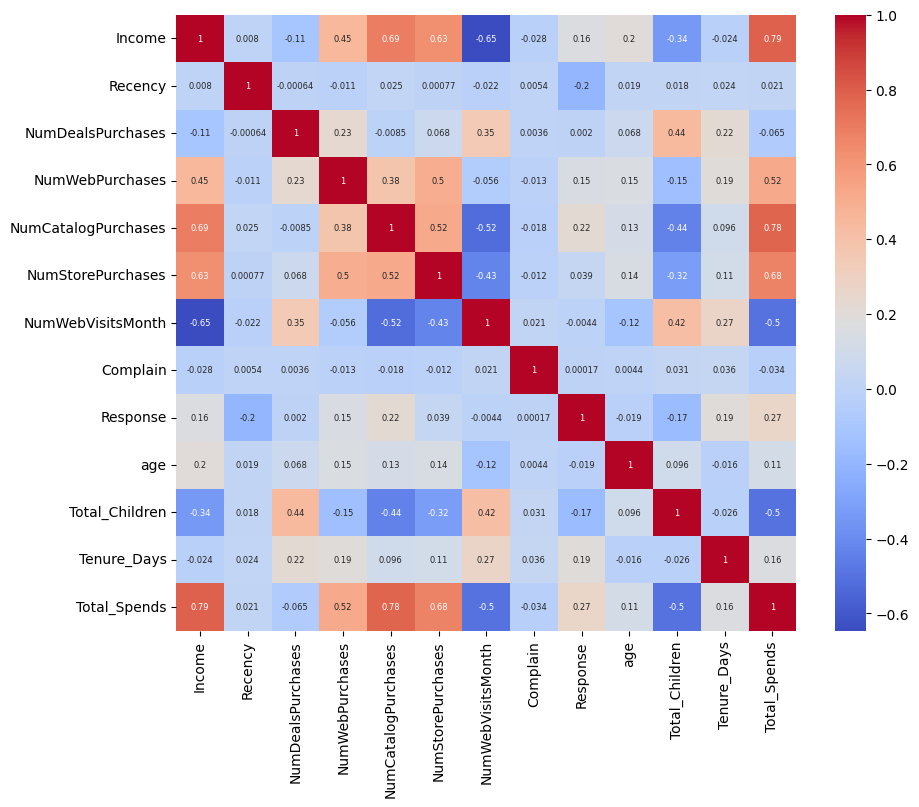

In [19]:
corr = df_cleaned.corr(numeric_only=True)

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size" : 6},
    cmap='coolwarm'
)

## Encoding

In [20]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder()

cat_cols = ['Education', 'Living_With']

encoded_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [21]:
enc_df = pd.DataFrame(encoded_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index=df_cleaned.index)

In [22]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols), enc_df], axis=1)

In [23]:
df_encoded.shape

(2236, 18)

In [24]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,Total_Children,Tenure_Days,Total_Spends,Education_Graduate,Education_Post Graduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,0,663,1617,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,2,113,27,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,0,312,776,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,1,139,53,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,1,161,422,0.0,1.0,0.0,0.0,1.0


## Feature Scaling

In [25]:
X = df_encoded

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## Visualize

In [26]:
from sklearn.decomposition import PCA

In [27]:
pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)

In [28]:
pca.explained_variance_ratio_

array([0.23162286, 0.11385437, 0.1040582 ])

Text(0.5, 0.92, '3d Projection')

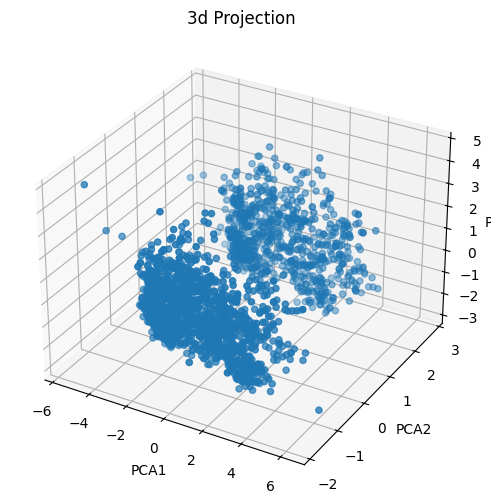

In [36]:
## plotting
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_pca[:,0],
    X_pca[:,1],
    X_pca[:,2],
)

ax.set_xlabel('PCA1')
ax.set_ylabel('PCA2')
ax.set_zlabel('PCA3')
ax.set_title('3d Projection')

## Analyizing K value

### 1. Elbow method

In [37]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [38]:
knee = KneeLocator(range(1,11), wcss, curve='convex', direction='decreasing')
optimal_k = knee.elbow

In [39]:
print(f"best k = {optimal_k}")

best k = 4


Text(0, 0.5, 'WCSS')

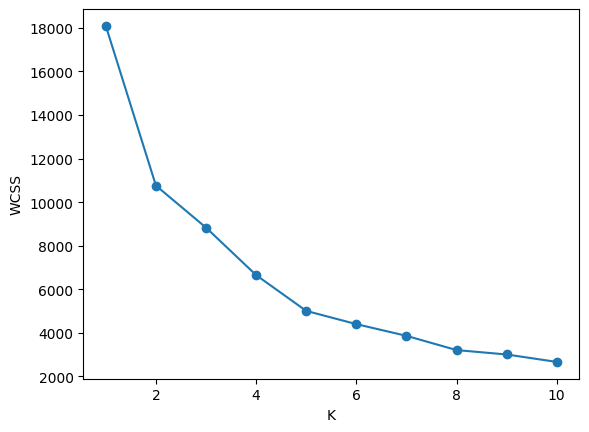

In [40]:
## plot 

plt.plot(range(1,11), wcss, marker = 'o')
plt.xlabel('K')
plt.ylabel('WCSS')

### 2. Silhouette Score

In [41]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    scores.append(silhouette_score(X_pca, labels))

Text(0, 0.5, 'Silhouette Score')

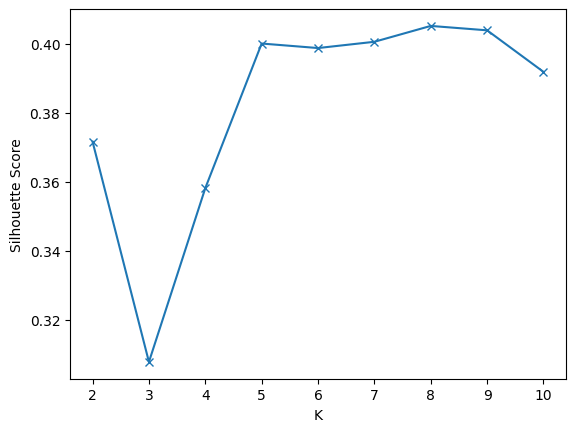

In [42]:
## plot 

plt.plot(range(2,11), scores, marker = 'x')
plt.xlabel('K')
plt.ylabel('Silhouette Score')

Text(0, 0.5, 'Silhouette Score')

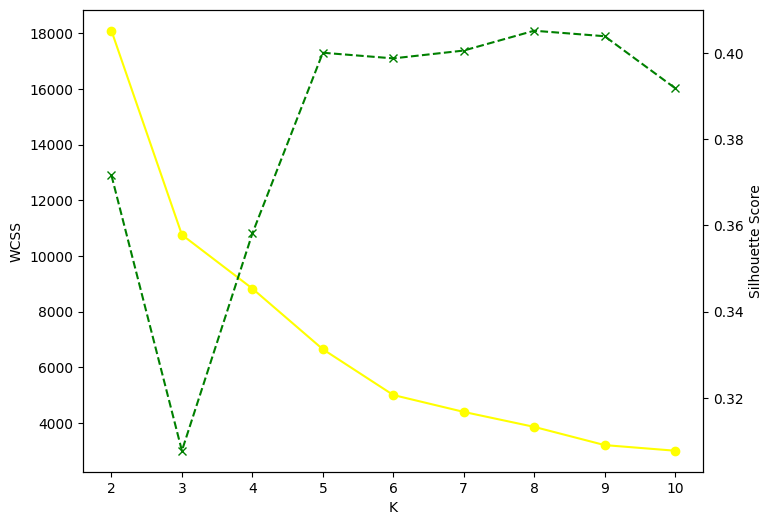

In [ ]:
## combined plot

k_range = range(2,11)

fig, ax1 = plt.subplots(figsize=(8,6))

ax1.plot(k_range, wcss[:len(k_range)], marker='o', color='yellow')
ax1.set_xlabel('K')
ax1.set_ylabel('WCSS')

ax2 = ax1.twinx()

ax2.plot(k_range, scores[:len(k_range)], marker='x', color='green', linestyle = '--')
ax2.set_xlabel('K')
ax2.set_ylabel('Silhouette Score')

## Clustering

In [44]:
# K_means

kmeans = KMeans(n_clusters=optimal_k, random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)

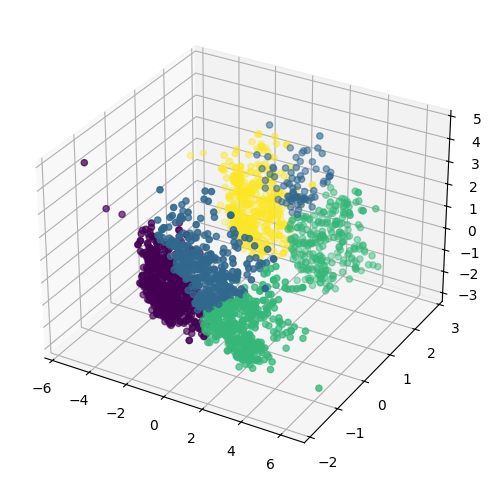

In [45]:
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_kmeans)

In [46]:
## Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering

In [47]:
agg_cls = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
labels_agg = agg_cls.fit_predict(X_pca)

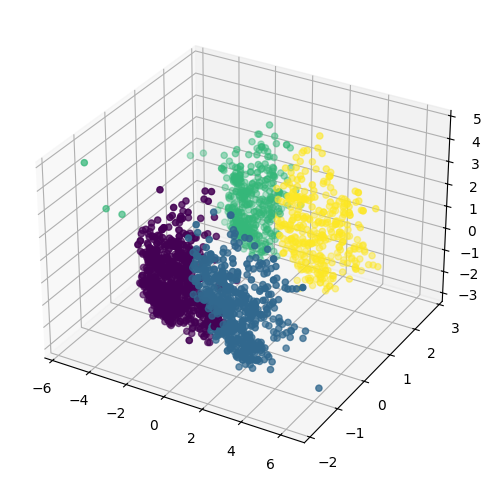

In [48]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_agg)

## Characterization of clusters

In [49]:
X["cluster"] = labels_agg

In [50]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,Total_Children,Tenure_Days,Total_Spends,Education_Graduate,Education_Post Graduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,0,663,1617,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,2,113,27,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,0,312,776,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,1,139,53,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,1,161,422,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='cluster', ylabel='count'>

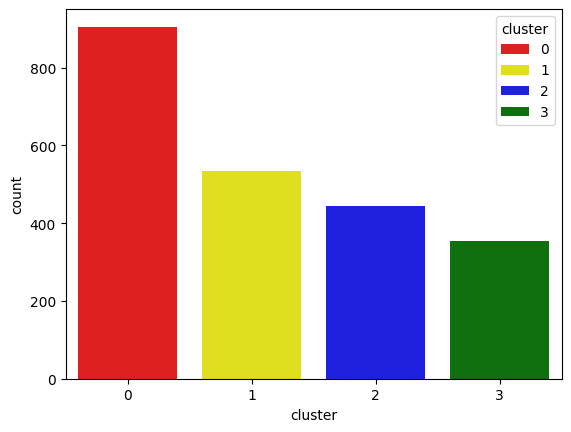

In [51]:
pal = ['red', 'yellow', 'blue', 'green']

sns.countplot(x=X['cluster'], palette=pal, hue=X['cluster'])

<Axes: xlabel='Total_Spends', ylabel='Income'>

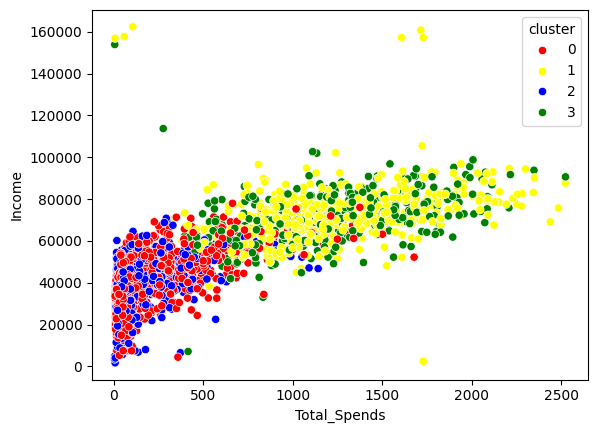

In [53]:
# Income & Spending patterns

sns.scatterplot(x=X["Total_Spends"], y=X["Income"], hue=X["cluster"], palette=pal)

In [55]:
cluster_summary = X.groupby('cluster').mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39690.146424  48.914917           2.594475         3.153591   
1        72814.930722  49.202247           1.958801         5.687266   
2        36973.792251  48.319820           2.594595         2.713964   
3        70730.038963  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        age  Total_Children  Tenure_Days  Total_Spends  \
cluster    